# 🏋️ RevFit Pose – Dataset Scan & Preprocessing

This notebook performs the full preprocessing pipeline on the **GYM exercise video dataset** stored in Google Drive:

1. **Mount Drive** and locate the dataset
2. **Extract** zip archives from Drive → local runtime (fast local disk)
3. **Scan** the extracted dataset – list all exercise classes, count videos/images
4. **Stage 1 – Landmark Extraction** – Run MediaPipe Pose and save raw landmarks as `.npy`
5. **Stage 2 – Feature Engineering** – Normalize, compute angles/velocities → `(T, 144)` features
6. **Summary report** with final statistics

---
## 1. Mount Google Drive & Install Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Install mediapipe only – keep Colab's numpy/protobuf/pandas untouched to avoid conflicts
import sys
!{sys.executable} -m pip install -q mediapipe

In [3]:
import os
import zipfile
import shutil
import numpy as np
import pandas as pd
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# Import Pose – newer mediapipe versions moved mp.solutions
# Use the same try/except pattern from process_video.py
try:
    MP_POSE = mp.solutions.pose
    print("Using: mp.solutions.pose")
except AttributeError:
    try:
        import mediapipe.python.solutions.pose as MP_POSE
        print("Using: mediapipe.python.solutions.pose")
    except ImportError:
        # Newest mediapipe uses the tasks API
        MP_POSE = None
        print("⚠️ mp.solutions.pose not available – will use tasks API")

print(f"MediaPipe version: {mp.__version__}")
print(f"OpenCV version:    {cv2.__version__}")
print(f"NumPy version:     {np.__version__}")

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


Using: mp.solutions.pose
MediaPipe version: 0.10.18
OpenCV version:    4.11.0
NumPy version:     1.26.4


---
## 2. Configure Paths

- **`DRIVE_DATASET_DIR`** — where the zips live on Google Drive  
- **`LOCAL_DATASET_DIR`** — where zips get extracted to (runtime local disk, much faster)  
- Outputs (Numpy, Features) also go to local runtime; copy them to Drive at the end if needed.

In [4]:
# ============================================================
# PATHS – Update these to match your Google Drive layout
# ============================================================
DRIVE_ROOT = '/content/drive/MyDrive/'

DRIVE_DATASET_DIR = os.path.join(DRIVE_ROOT, 'GYM')

if not os.path.isdir(DRIVE_DATASET_DIR):
    alt = os.path.join(DRIVE_ROOT, 'Fitness-AQA_dataset_release')
    if os.path.isdir(alt):
        DRIVE_DATASET_DIR = alt
        print(f"Using alternative dataset directory: {DRIVE_DATASET_DIR}")
    else:
        raise FileNotFoundError(
            f"Dataset directory not found at {DRIVE_DATASET_DIR}\n"
            f"Please update DRIVE_DATASET_DIR to point to your dataset folder."
        )

LOCAL_DATASET_DIR = '/content/dataset'
NUMPY_DIR         = '/content/dataset_numpy'
FEATURES_DIR      = '/content/dataset_features'

print(f"Drive source    : {DRIVE_DATASET_DIR}")
print(f"Local extracted : {LOCAL_DATASET_DIR}")
print(f"Numpy output    : {NUMPY_DIR}")
print(f"Feature output  : {FEATURES_DIR}")

Using alternative dataset directory: /content/drive/MyDrive/Fitness-AQA_dataset_release
Drive source    : /content/drive/MyDrive/Fitness-AQA_dataset_release
Local extracted : /content/dataset
Numpy output    : /content/dataset_numpy
Feature output  : /content/dataset_features


---
## 3. Extract Zip Archives → Local Runtime

Finds all `.zip` files on Drive (recursively) and extracts them to **local runtime disk** (`/content/dataset/`).  
Already-extracted zips are skipped automatically.

In [5]:
VIDEO_EXTENSIONS = {'.mp4', '.avi', '.mov', '.mkv', '.webm', '.flv', '.wmv'}
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
ALL_MEDIA_EXTENSIONS = VIDEO_EXTENSIONS | IMAGE_EXTENSIONS


def extract_dataset_to_local(drive_dir, local_dir):
    os.makedirs(local_dir, exist_ok=True)

    classes = sorted([
        d for d in os.listdir(drive_dir)
        if os.path.isdir(os.path.join(drive_dir, d)) and not d.startswith('.')
    ])

    stats = {'zips_extracted': 0, 'zips_skipped': 0, 'files_copied': 0, 'files_skipped': 0, 'errors': 0}

    for class_name in tqdm(classes, desc='Extracting to local'):
        drive_class_path = os.path.join(drive_dir, class_name)
        local_class_path = os.path.join(local_dir, class_name)
        os.makedirs(local_class_path, exist_ok=True)

        for root, dirs, files in os.walk(drive_class_path):
            rel = os.path.relpath(root, drive_class_path)
            local_subdir = os.path.join(local_class_path, rel) if rel != '.' else local_class_path
            os.makedirs(local_subdir, exist_ok=True)

            for fname in sorted(files):
                src = os.path.join(root, fname)
                ext = os.path.splitext(fname)[1].lower()

                if ext == '.zip':
                    marker = os.path.join(local_subdir, fname + '.extracted')
                    if os.path.exists(marker):
                        stats['zips_skipped'] += 1
                        continue
                    try:
                        with zipfile.ZipFile(src, 'r') as zf:
                            members = zf.namelist()
                            media_count = sum(
                                1 for m in members
                                if os.path.splitext(m)[1].lower() in ALL_MEDIA_EXTENSIONS
                            )
                            print(f"  📦 {class_name}/{fname}: {len(members)} entries ({media_count} media)")
                            zf.extractall(local_subdir)
                        with open(marker, 'w') as mf:
                            mf.write(f'Extracted {len(members)} files')
                        stats['zips_extracted'] += 1
                    except zipfile.BadZipFile:
                        print(f"  ❌ {fname}: Not a valid zip file, skipping.")
                        stats['errors'] += 1
                    except Exception as e:
                        print(f"  ❌ {fname}: Error – {e}")
                        stats['errors'] += 1

                elif ext in ALL_MEDIA_EXTENSIONS:
                    dst = os.path.join(local_subdir, fname)
                    if os.path.exists(dst):
                        stats['files_skipped'] += 1
                        continue
                    try:
                        shutil.copy2(src, dst)
                        stats['files_copied'] += 1
                    except Exception as e:
                        print(f"  ❌ Copy error {fname}: {e}")
                        stats['errors'] += 1

    print(f"\n--- Extraction Summary ---")
    print(f"  Zips extracted     : {stats['zips_extracted']}")
    print(f"  Zips skipped (done): {stats['zips_skipped']}")
    print(f"  Files copied       : {stats['files_copied']}")
    print(f"  Files skipped      : {stats['files_skipped']}")
    print(f"  Errors             : {stats['errors']}")


extract_dataset_to_local(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR)

DATASET_DIR = LOCAL_DATASET_DIR
print(f"\nDataset dir for processing: {DATASET_DIR}")

Extracting to local:   0%|          | 0/3 [00:00<?, ?it/s]


--- Extraction Summary ---
  Zips extracted     : 0
  Zips skipped (done): 8
  Files copied       : 0
  Files skipped      : 0
  Errors             : 0

Dataset dir for processing: /content/dataset


---
## 4. Scan the Dataset

In [6]:
def scan_dataset(dataset_dir):
    records = []
    classes = sorted([
        d for d in os.listdir(dataset_dir)
        if os.path.isdir(os.path.join(dataset_dir, d)) and not d.startswith('.')
    ])

    for class_name in classes:
        class_path = os.path.join(dataset_dir, class_name)
        for root, dirs, files in os.walk(class_path):
            for f in sorted(files):
                ext = os.path.splitext(f)[1].lower()
                if ext in ALL_MEDIA_EXTENSIONS:
                    records.append({
                        'class': class_name,
                        'filename': f,
                        'type': 'video' if ext in VIDEO_EXTENSIONS else 'image',
                        'path': os.path.join(root, f)
                    })

    df = pd.DataFrame(records, columns=['class', 'filename', 'type', 'path'])
    return df, classes

df_dataset, exercise_classes = scan_dataset(DATASET_DIR)

n_videos = len(df_dataset[df_dataset['type'] == 'video'])
n_images = len(df_dataset[df_dataset['type'] == 'image'])
print(f"Found {len(exercise_classes)} exercise classes")
print(f"  {n_videos} video files")
print(f"  {n_images} image files")
print(f"  {len(df_dataset)} total media files\n")

print("Exercise classes:")
for i, c in enumerate(exercise_classes, 1):
    subset = df_dataset[df_dataset['class'] == c]
    nv = len(subset[subset['type'] == 'video'])
    ni = len(subset[subset['type'] == 'image'])
    print(f"  {i:2d}. {c}  ({nv} videos, {ni} images)")

if len(df_dataset) == 0:
    print('\n⚠️  No media files found after extraction!')
    print(f'   DATASET_DIR = {DATASET_DIR}')
    if os.path.isdir(DATASET_DIR):
        print(f'   Top-level contents: {os.listdir(DATASET_DIR)[:20]}')

Found 3 exercise classes
  14566 video files
  37497 image files
  52063 total media files

Exercise classes:
   1. BarbellRow  (0 videos, 33759 images)
   2. OHP  (7857 videos, 0 images)
   3. Squat  (6709 videos, 3738 images)


In [7]:
# Distribution table
if len(df_dataset) == 0:
    print('No media files found — skipping distribution table.')
else:
    summary_rows = []
    for c in sorted(df_dataset['class'].unique()):
        subset = df_dataset[df_dataset['class'] == c]
        summary_rows.append({
            'Exercise Class': c,
            'Videos': len(subset[subset['type'] == 'video']),
            'Images': len(subset[subset['type'] == 'image']),
            'Total': len(subset),
        })
    summary_df = pd.DataFrame(summary_rows)
    summary_df.index += 1
    summary_df.index.name = '#'
    print(summary_df.to_string())
    print(f"\nTotal: {summary_df['Videos'].sum()} videos, {summary_df['Images'].sum()} images, {summary_df['Total'].sum()} files")

  Exercise Class  Videos  Images  Total
#                                      
1     BarbellRow       0   33759  33759
2            OHP    7857       0   7857
3          Squat    6709    3738  10447

Total: 14566 videos, 37497 images, 52063 files


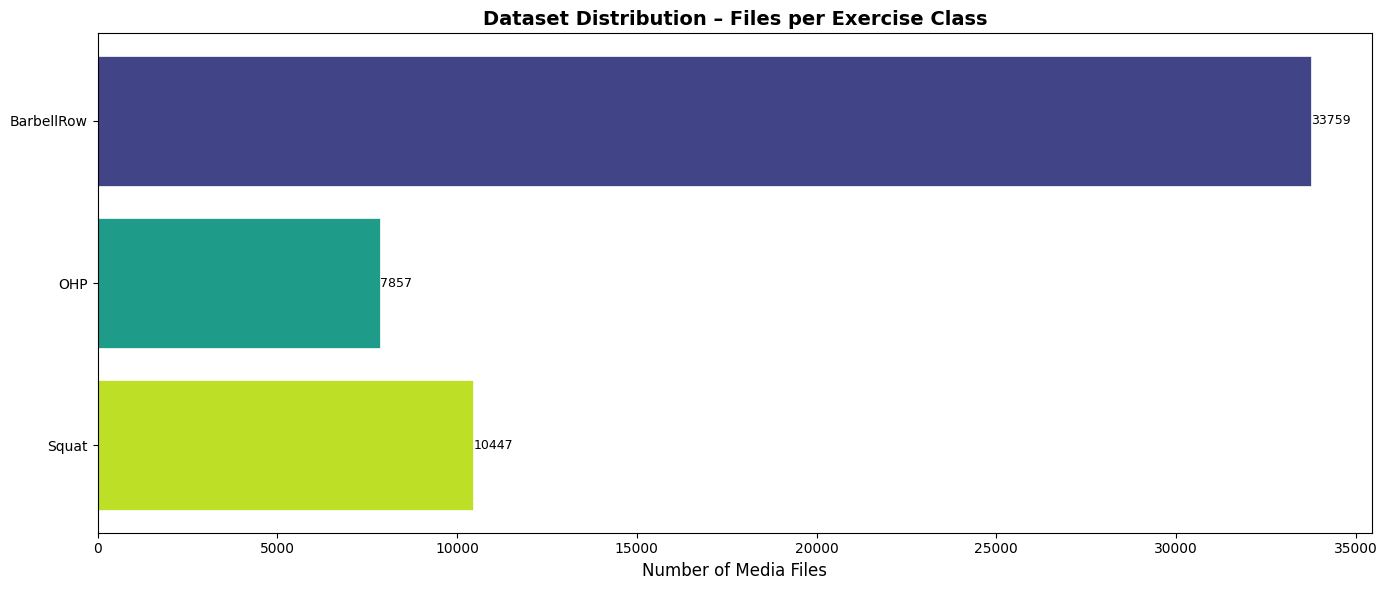

In [8]:
# Bar chart
if len(df_dataset) > 0:
    class_counts = df_dataset['class'].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(14, 6))
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(class_counts)))
    bars = ax.barh(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Number of Media Files', fontsize=12)
    ax.set_title('Dataset Distribution – Files per Exercise Class', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    for bar, count in zip(bars, class_counts.values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('Skipping chart — no media files found.')

---
## 5. Stage 1 – MediaPipe Landmark Extraction

For each exercise video/image, run **MediaPipe Pose** to extract 33 body landmarks per frame.  
Output: one `.npy` file per media item with shape `(T, 33, 4)` — `[x, y, z, visibility]`.  

Supports both the legacy `mp.solutions.pose` API and the newer **Tasks API**.

In [9]:
# Download the pose landmarker model for the Tasks API (if needed)
MODEL_PATH = '/content/pose_landmarker_lite.task'

if MP_POSE is None and not os.path.exists(MODEL_PATH):
    print("Downloading pose landmarker model for Tasks API...")
    !wget -q -O {MODEL_PATH} https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task
    print(f"  ✅ Downloaded to {MODEL_PATH}")
elif MP_POSE is not None:
    print("Using legacy mp.solutions.pose API – no model download needed.")

Using legacy mp.solutions.pose API – no model download needed.


In [10]:
def convert_to_mp4(input_path, output_path):
    """Convert a non-MP4 video to MP4 format."""
    cap = cv2.VideoCapture(input_path)
    fps = int(cap.get(cv2.CAP_PROP_FPS)) or 30
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        out.write(frame)
    cap.release()
    out.release()


# ============================================================
# Legacy API (mp.solutions.pose) – mediapipe <= 0.10.18
# ============================================================
def _extract_video_legacy(video_path):
    pose = MP_POSE.Pose(
        static_image_mode=False,
        model_complexity=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        pose.close()
        return None

    landmarks = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(rgb)
        if results.pose_landmarks:
            landmarks.append([[lm.x, lm.y, lm.z, lm.visibility]
                              for lm in results.pose_landmarks.landmark])
    cap.release()
    pose.close()
    return np.array(landmarks) if landmarks else None


def _extract_image_legacy(image_path):
    pose = MP_POSE.Pose(
        static_image_mode=True,
        model_complexity=1,
        min_detection_confidence=0.5
    )
    image = cv2.imread(image_path)
    if image is None:
        pose.close()
        return None
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose.process(rgb)
    pose.close()
    if not results.pose_landmarks:
        return None
    lm = [[l.x, l.y, l.z, l.visibility] for l in results.pose_landmarks.landmark]
    return np.array([lm])  # (1, 33, 4)


# ============================================================
# Tasks API (mediapipe >= 0.10.21) – no mp.solutions
# ============================================================
def _extract_image_tasks(image_path):
    from mediapipe.tasks.python import vision, BaseOptions
    from mediapipe.tasks.python.vision import PoseLandmarker, PoseLandmarkerOptions, RunningMode

    options = PoseLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=RunningMode.IMAGE,
        num_poses=1
    )
    with PoseLandmarker.create_from_options(options) as landmarker:
        mp_image = mp.Image.create_from_file(image_path)
        result = landmarker.detect(mp_image)

        if not result.pose_landmarks:
            return None

        lm = result.pose_landmarks[0]
        frame_lm = [[l.x, l.y, l.z, l.visibility] for l in lm]
        return np.array([frame_lm])  # (1, 33, 4)


def _extract_video_tasks(video_path):
    from mediapipe.tasks.python import vision, BaseOptions
    from mediapipe.tasks.python.vision import PoseLandmarker, PoseLandmarkerOptions, RunningMode

    options = PoseLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=RunningMode.VIDEO,
        num_poses=1
    )
    with PoseLandmarker.create_from_options(options) as landmarker:
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            return None

        fps = cap.get(cv2.CAP_PROP_FPS) or 30
        landmarks = []
        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            timestamp_ms = int(frame_idx * 1000.0 / fps)
            result = landmarker.detect_for_video(mp_image, timestamp_ms)

            if result.pose_landmarks:
                lm = result.pose_landmarks[0]
                landmarks.append([[l.x, l.y, l.z, l.visibility] for l in lm])
            frame_idx += 1

        cap.release()
    return np.array(landmarks) if landmarks else None


# ============================================================
# Unified extraction functions
# ============================================================
def extract_landmarks_from_video(video_path):
    if not video_path.lower().endswith('.mp4'):
        mp4_path = os.path.splitext(video_path)[0] + '.mp4'
        if not os.path.exists(mp4_path):
            convert_to_mp4(video_path, mp4_path)
        video_path = mp4_path

    if MP_POSE is not None:
        return _extract_video_legacy(video_path)
    else:
        return _extract_video_tasks(video_path)


def extract_landmarks_from_image(image_path):
    if MP_POSE is not None:
        return _extract_image_legacy(image_path)
    else:
        return _extract_image_tasks(image_path)

In [11]:
# ============================================================
# Run Stage 1: Extract landmarks for all media files
# ============================================================
if len(df_dataset) == 0:
    print('⚠️ No media files to process. Fix DATASET_DIR first.')
else:
    os.makedirs(NUMPY_DIR, exist_ok=True)

    stage1_stats = {'processed': 0, 'skipped_existing': 0, 'failed': 0, 'no_landmarks': 0}

    for class_name in tqdm(exercise_classes, desc='Stage 1 – Extracting landmarks'):
        save_class_path = os.path.join(NUMPY_DIR, class_name)
        os.makedirs(save_class_path, exist_ok=True)

        class_files = df_dataset[df_dataset['class'] == class_name]

        for _, row in class_files.iterrows():
            file_id = os.path.splitext(row['filename'])[0]
            save_path = os.path.join(save_class_path, f"{file_id}.npy")

            if os.path.exists(save_path):
                stage1_stats['skipped_existing'] += 1
                continue

            try:
                if row['type'] == 'video':
                    landmarks = extract_landmarks_from_video(row['path'])
                else:
                    landmarks = extract_landmarks_from_image(row['path'])
            except Exception as e:
                print(f"  ❌ Error: {class_name}/{row['filename']}: {e}")
                stage1_stats['failed'] += 1
                continue

            if landmarks is None:
                print(f"  ⚠️ No landmarks: {class_name}/{row['filename']}")
                stage1_stats['no_landmarks'] += 1
                continue

            np.save(save_path, landmarks)
            stage1_stats['processed'] += 1

    print("\n--- Stage 1 Summary ---")
    print(f"  Newly processed : {stage1_stats['processed']}")
    print(f"  Skipped (exist) : {stage1_stats['skipped_existing']}")
    print(f"  No landmarks    : {stage1_stats['no_landmarks']}")
    print(f"  Failed          : {stage1_stats['failed']}")

Stage 1 – Extracting landmarks:   0%|          | 0/3 [00:00<?, ?it/s]

  ⚠️ No landmarks: BarbellRow/52701_11_1.jpg
  ⚠️ No landmarks: BarbellRow/52701_11_15.jpg
  ⚠️ No landmarks: BarbellRow/52701_11_27.jpg
  ⚠️ No landmarks: BarbellRow/52701_11_30.jpg
  ⚠️ No landmarks: BarbellRow/52701_11_35.jpg
  ⚠️ No landmarks: BarbellRow/52701_11_4.jpg
  ⚠️ No landmarks: BarbellRow/52701_11_40.jpg
  ⚠️ No landmarks: BarbellRow/52701_11_48.jpg
  ⚠️ No landmarks: BarbellRow/52701_11_51.jpg
  ⚠️ No landmarks: BarbellRow/52701_11_55.jpg
  ⚠️ No landmarks: BarbellRow/52701_11_56.jpg
  ⚠️ No landmarks: BarbellRow/52701_11_57.jpg
  ⚠️ No landmarks: BarbellRow/52701_11_58.jpg
  ⚠️ No landmarks: BarbellRow/52701_11_62.jpg
  ⚠️ No landmarks: BarbellRow/52730_7_28.jpg
  ⚠️ No landmarks: BarbellRow/52731_4_10.jpg
  ⚠️ No landmarks: BarbellRow/52731_4_11.jpg
  ⚠️ No landmarks: BarbellRow/52731_4_12.jpg
  ⚠️ No landmarks: BarbellRow/52731_4_25.jpg
  ⚠️ No landmarks: BarbellRow/52731_4_27.jpg
  ⚠️ No landmarks: BarbellRow/52735_4_0.jpg
  ⚠️ No landmarks: BarbellRow/52735_4_13.jpg

: 

---
## 6. Stage 2 – Feature Engineering

For each `.npy` landmarks file, compute:
- **Normalized landmarks** (hip-centred, torso-length scaled) → 33×2 = 66 features
- **Landmark velocity** (frame-to-frame Δ) → 33×2 = 66 features
- **Joint angles** (elbow, knee, hip – left & right) → 6 features
- **Angular velocity** → 6 features

Total: **144 features** per frame → output shape `(T, 144)`

In [ ]:
POSE_IDX = {
    "LEFT_SHOULDER": 11,  "RIGHT_SHOULDER": 12,
    "LEFT_ELBOW":    13,  "RIGHT_ELBOW":    14,
    "LEFT_WRIST":    15,  "RIGHT_WRIST":    16,
    "LEFT_HIP":      23,  "RIGHT_HIP":      24,
    "LEFT_KNEE":     25,  "RIGHT_KNEE":     26,
    "LEFT_ANKLE":    27,  "RIGHT_ANKLE":    28,
    "NOSE":           0,
}

VIS_THRESHOLD = 0.5

ANGLE_DEFINITIONS = [
    ("LEFT_ELBOW",  [POSE_IDX["LEFT_SHOULDER"],  POSE_IDX["LEFT_ELBOW"],  POSE_IDX["LEFT_WRIST"]]),
    ("RIGHT_ELBOW", [POSE_IDX["RIGHT_SHOULDER"], POSE_IDX["RIGHT_ELBOW"], POSE_IDX["RIGHT_WRIST"]]),
    ("LEFT_KNEE",   [POSE_IDX["LEFT_HIP"],       POSE_IDX["LEFT_KNEE"],   POSE_IDX["LEFT_ANKLE"]]),
    ("RIGHT_KNEE",  [POSE_IDX["RIGHT_HIP"],      POSE_IDX["RIGHT_KNEE"],  POSE_IDX["RIGHT_ANKLE"]]),
    ("LEFT_HIP",    [POSE_IDX["LEFT_SHOULDER"],  POSE_IDX["LEFT_HIP"],    POSE_IDX["LEFT_KNEE"]]),
    ("RIGHT_HIP",   [POSE_IDX["RIGHT_SHOULDER"], POSE_IDX["RIGHT_HIP"],   POSE_IDX["RIGHT_KNEE"]]),
]


def angle_3d(a, b, c):
    ba = a - b
    bc = c - b
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))


def joints_visible(frame, joint_ids, threshold=VIS_THRESHOLD):
    return all(frame[j, 3] >= threshold for j in joint_ids)


def extract_angles(frame, prev_angles=None):
    lm = frame[:, :2]
    angles = []
    for i, (name, joints) in enumerate(ANGLE_DEFINITIONS):
        if joints_visible(frame, joints):
            angles.append(angle_3d(lm[joints[0]], lm[joints[1]], lm[joints[2]]))
        else:
            angles.append(prev_angles[i] if prev_angles is not None else 0.0)
    return np.array(angles)


def normalize_landmarks(lm):
    left_hip  = lm[:, 23, :2]
    right_hip = lm[:, 24, :2]
    hip_center = (left_hip + right_hip) / 2
    lm[:, :, :2] -= hip_center[:, None, :]

    left_sh  = lm[:, 11, :2]
    right_sh = lm[:, 12, :2]
    shoulder_center = (left_sh + right_sh) / 2
    torso_length = np.linalg.norm(shoulder_center - hip_center, axis=1)
    torso_length[torso_length == 0] = 1e-6
    lm[:, :, :2] /= torso_length[:, None, None]
    return lm


def process_video_features(video):
    T = video.shape[0]
    lm_norm = normalize_landmarks(video.copy())

    lm_vel = np.zeros_like(lm_norm[:, :, :2])
    lm_vel[1:] = lm_norm[1:, :, :2] - lm_norm[:-1, :, :2]

    angles_all = []
    prev_angles = None
    for frame in video:
        angles = extract_angles(frame, prev_angles)
        angles_all.append(angles)
        prev_angles = angles
    angles_all = np.array(angles_all)

    angle_vel = np.zeros_like(angles_all)
    angle_vel[1:] = angles_all[1:] - angles_all[:-1]

    lm_flat     = lm_norm[:, :, :2].reshape(T, -1)
    lm_vel_flat = lm_vel.reshape(T, -1)

    features = np.concatenate([lm_flat, lm_vel_flat, angles_all, angle_vel], axis=1)
    return features  # (T, 144)

In [ ]:
# ============================================================
# Run Stage 2: Feature engineering on extracted landmarks
# ============================================================
if not os.path.isdir(NUMPY_DIR):
    print('⚠️ Numpy directory not found. Run Stage 1 first.')
else:
    os.makedirs(FEATURES_DIR, exist_ok=True)

    stage2_stats = {'processed': 0, 'skipped_existing': 0, 'failed': 0}

    numpy_classes = sorted([
        d for d in os.listdir(NUMPY_DIR)
        if os.path.isdir(os.path.join(NUMPY_DIR, d))
    ])

    for class_name in tqdm(numpy_classes, desc='Stage 2 – Feature engineering'):
        npy_class_path = os.path.join(NUMPY_DIR, class_name)
        save_class_path = os.path.join(FEATURES_DIR, class_name)
        os.makedirs(save_class_path, exist_ok=True)

        npy_files = sorted([f for f in os.listdir(npy_class_path) if f.endswith('.npy')])

        for npy_file in npy_files:
            output_path = os.path.join(save_class_path, npy_file)

            if os.path.exists(output_path):
                stage2_stats['skipped_existing'] += 1
                continue

            try:
                video = np.load(os.path.join(npy_class_path, npy_file))
                features = process_video_features(video)
                np.save(output_path, features)
                stage2_stats['processed'] += 1
            except Exception as e:
                print(f"  ❌ Error: {class_name}/{npy_file}: {e}")
                stage2_stats['failed'] += 1

    print("\n--- Stage 2 Summary ---")
    print(f"  Newly processed : {stage2_stats['processed']}")
    print(f"  Skipped (exist) : {stage2_stats['skipped_existing']}")
    print(f"  Failed          : {stage2_stats['failed']}")

---
## 7. Final Summary & Verification

In [ ]:
def scan_output_dir(output_dir):
    rows = []
    if not os.path.isdir(output_dir):
        return pd.DataFrame()
    for class_name in sorted(os.listdir(output_dir)):
        class_path = os.path.join(output_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        npy_files = [f for f in os.listdir(class_path) if f.endswith('.npy')]
        shapes = []
        for f in npy_files:
            try:
                arr = np.load(os.path.join(class_path, f))
                shapes.append(arr.shape)
            except:
                pass
        total_frames = sum(s[0] for s in shapes) if shapes else 0
        feat_dim = shapes[0][1:] if shapes else 'N/A'
        rows.append({
            'Class': class_name,
            'Files': len(npy_files),
            'Total Frames': total_frames,
            'Feature Shape': str(feat_dim),
            'Min Frames': min(s[0] for s in shapes) if shapes else 0,
            'Max Frames': max(s[0] for s in shapes) if shapes else 0,
        })
    return pd.DataFrame(rows)

print("=" * 60)
print("  LANDMARK FILES  (Stage 1 output)")
print("=" * 60)
df_lm = scan_output_dir(NUMPY_DIR)
if len(df_lm) > 0:
    print(df_lm.to_string(index=False))
    print(f"\nTotal: {df_lm['Files'].sum()} files, {df_lm['Total Frames'].sum()} frames")
else:
    print("No landmark files found.")

print("\n" + "=" * 60)
print("  FEATURE FILES  (Stage 2 output)")
print("=" * 60)
df_ft = scan_output_dir(FEATURES_DIR)
if len(df_ft) > 0:
    print(df_ft.to_string(index=False))
    print(f"\nTotal: {df_ft['Files'].sum()} files, {df_ft['Total Frames'].sum()} frames")
else:
    print("No feature files found.")

In [ ]:
# Quick sanity check
if len(df_ft) > 0:
    sample_class = df_ft.iloc[0]['Class']
    sample_dir = os.path.join(FEATURES_DIR, sample_class)
    sample_file = sorted(os.listdir(sample_dir))[0]
    sample = np.load(os.path.join(sample_dir, sample_file))
    print(f"Sample: {sample_class}/{sample_file}")
    print(f"  Shape: {sample.shape}")
    print(f"  Dtype: {sample.dtype}")
    print(f"  Min:   {sample.min():.4f}")
    print(f"  Max:   {sample.max():.4f}")
    print(f"  Mean:  {sample.mean():.4f}")
    print(f"  NaN count: {np.isnan(sample).sum()}")
    print(f"\n  Feature breakdown:")
    print(f"    Columns  0-65  : Normalized landmarks (33 joints x 2 coords)")
    print(f"    Columns 66-131 : Landmark velocities  (33 joints x 2 coords)")
    print(f"    Columns 132-137: Joint angles (L/R elbow, knee, hip)")
    print(f"    Columns 138-143: Angular velocities")
else:
    print("No feature files to inspect.")

---
## 8. (Optional) Copy Results Back to Drive

In [ ]:
SAVE_TO_DRIVE = False  # Set to False to skip

if SAVE_TO_DRIVE:
    drive_numpy    = os.path.join(DRIVE_ROOT, 'Numpy')
    drive_features = os.path.join(DRIVE_ROOT, 'Features')

    if os.path.isdir(NUMPY_DIR):
        print(f"Copying landmarks → {drive_numpy} ...")
        shutil.copytree(NUMPY_DIR, drive_numpy, dirs_exist_ok=True)
        print("  ✅ Done.")

    if os.path.isdir(FEATURES_DIR):
        print(f"Copying features  → {drive_features} ...")
        shutil.copytree(FEATURES_DIR, drive_features, dirs_exist_ok=True)
        print("  ✅ Done.")

    print("\n✅ Results saved to Google Drive!")
else:
    print("Skipping Drive copy.")
    print("⚠️ Results will be lost when the runtime disconnects!")

In [ ]:
print("\n✅ Preprocessing pipeline complete!")
print(f"   Local landmarks : {NUMPY_DIR}")
print(f"   Local features  : {FEATURES_DIR}")